In [1]:
import pandas as pd

# Load both datasets
df1 = pd.read_csv(r'C:\Users\Sahil Sutar\Downloads\coin_gecko_2022-03-16.csv')
df2 = pd.read_csv(r'C:\Users\Sahil Sutar\Downloads\coin_gecko_2022-03-17.csv')

# Check basic info
print("First Dataset (2022-03-16):")
print(df1.shape)
print(df1.columns)

print("\nSecond Dataset (2022-03-17):")
print(df2.shape)
print(df2.columns)

# See first few rows
df1.head()
df2.head()


First Dataset (2022-03-16):
(500, 9)
Index(['coin', 'symbol', 'price', '1h', '24h', '7d', '24h_volume', 'mkt_cap',
       'date'],
      dtype='object')

Second Dataset (2022-03-17):
(500, 9)
Index(['coin', 'symbol', 'price', '1h', '24h', '7d', '24h_volume', 'mkt_cap',
       'date'],
      dtype='object')


,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40851.380000,0.001,0.000,-0.027,2.047612e+10,7.760774e+11,2022-03-17
1,Ethereum,ETH,2824.420000,0.004,0.029,0.034,1.364041e+10,3.390772e+11,2022-03-17
2,Tether,USDT,1.000000,-0.000,0.000,0.000,4.413140e+10,8.020588e+10,2022-03-17
3,BNB,BNB,389.610000,0.002,0.016,-0.010,1.425354e+09,6.556116e+10,2022-03-17
4,USD Coin,USDC,0.999739,-0.001,0.000,-0.000,3.569816e+09,5.259607e+10,2022-03-17


In [9]:
import os

# Create "data" folder if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

# Now save the file
df.to_csv('data/crypto_combined.csv', index=False)


In [11]:
# Step 1: Concatenate the two datasets
df = pd.concat([df1, df2], ignore_index=True)

# Step 2: Check the combined data
print(df.shape)
df.head()

# Step 3: Save the merged data
df.to_csv('data/crypto_combined.csv', index=False)


(1000, 9)


Step 2: Data Preprocessing (In-Depth)

In [14]:
import pandas as pd

# Load combined dataset
df = pd.read_csv('data/crypto_combined.csv')

# View first few rows
df.head()


,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16


In [16]:
# Check how many missing values
df.isnull().sum()


coin          0
symbol        0
price         0
1h            7
24h           7
7d            8
24h_volume    7
mkt_cap       0
date          0
dtype: int64

In [18]:
# Drop rows with missing data
df.dropna(inplace=True)

# Confirm again
df.isnull().sum()


coin          0
symbol        0
price         0
1h            0
24h           0
7d            0
24h_volume    0
mkt_cap       0
date          0
dtype: int64

In [20]:
# Check data types
df.dtypes


coin           object
symbol         object
price         float64
1h            float64
24h           float64
7d            float64
24h_volume    float64
mkt_cap       float64
date           object
dtype: object

In [22]:
# Example: Convert price column to float if not already
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['24h_volume'] = pd.to_numeric(df['24h_volume'], errors='coerce')
df['mkt_cap'] = pd.to_numeric(df['mkt_cap'], errors='coerce')


In [24]:
# Create a new DataFrame for modeling
features = ['price', '1h', '24h', '7d', '24h_volume', 'mkt_cap']
df_features = df[features]


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform
df_scaled = scaler.fit_transform(df_features)

# Convert back to DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=features)

# View scaled data
df_scaled.head()


,price,1h,24h,7d,24h_volume,mkt_cap
0,9.104415,0.457835,0.102013,0.136901,12.673320,20.099515
1,0.480649,0.532174,0.170228,0.180443,7.025914,8.470440
2,-0.140064,-0.397060,-0.426652,-0.102577,20.812672,1.995816
3,-0.053537,0.309157,0.067905,-0.085161,0.399812,1.578705
4,-0.140064,-0.397060,-0.409599,-0.102577,1.293897,1.268997


Step 3: Exploratory Data Analysis (EDA)

In [28]:
# Summary statistics
df_features.describe()


,price,1h,24h,7d,24h_volume,mkt_cap
count,9.920000e+02,992.000000,992.000000,992.000000,9.920000e+02,9.920000e+02
mean,6.200521e+02,0.009682,0.024018,0.023558,2.884638e+08,3.783951e+09
std,4.421998e+03,0.026917,0.058668,0.229781,2.771176e+09,3.818970e+10
min,1.484000e-09,-0.704000,-0.646000,-0.558000,0.000000e+00,6.577043e+07
25%,1.940547e-01,0.001000,0.001000,-0.041000,1.764198e+06,1.158501e+08
50%,1.095000e+00,0.006000,0.016000,-0.000500,8.328741e+06,2.131953e+08
75%,6.955000e+00,0.019000,0.035000,0.037000,3.947222e+07,5.972493e+08
max,4.121727e+04,0.095000,0.577000,4.608000,5.793497e+10,7.760774e+11


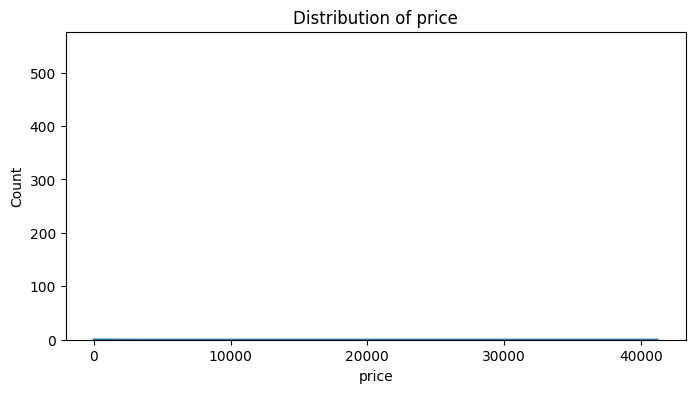

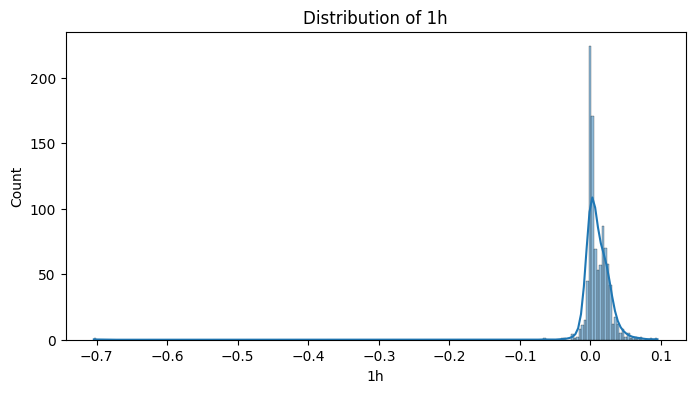

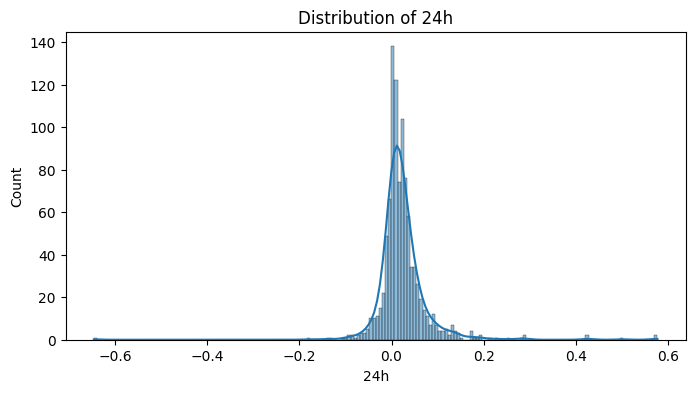

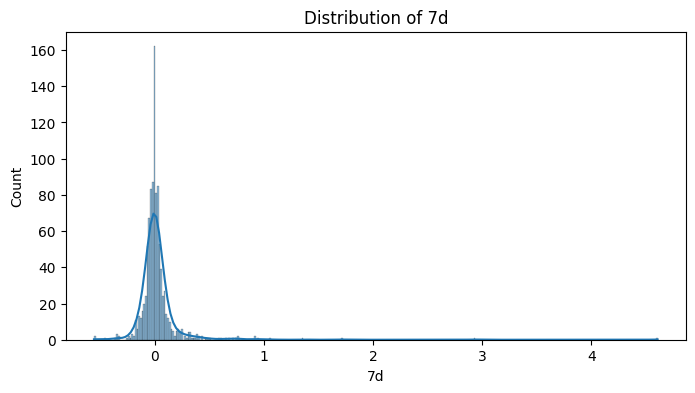

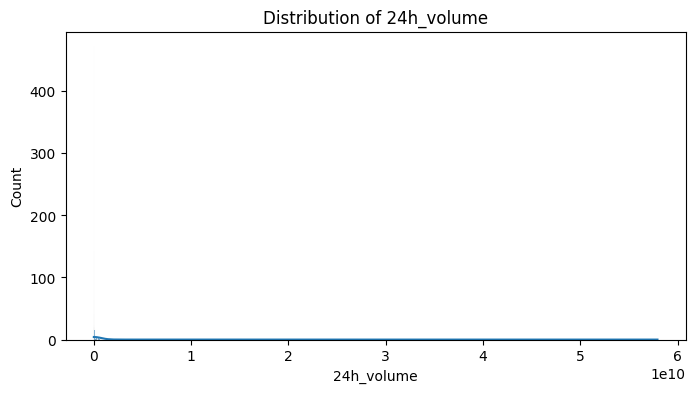

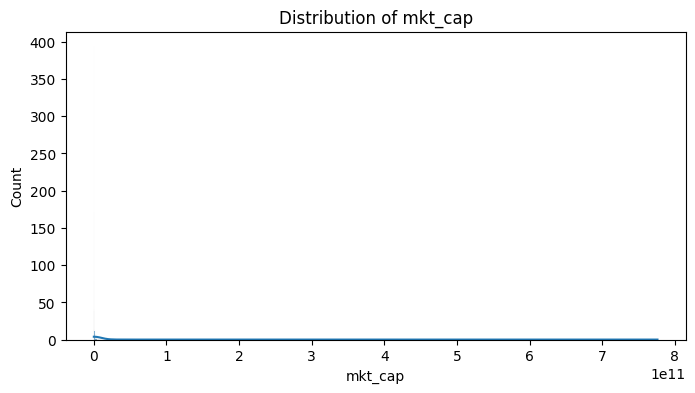

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distribution of each feature
for col in df_features.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_features[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


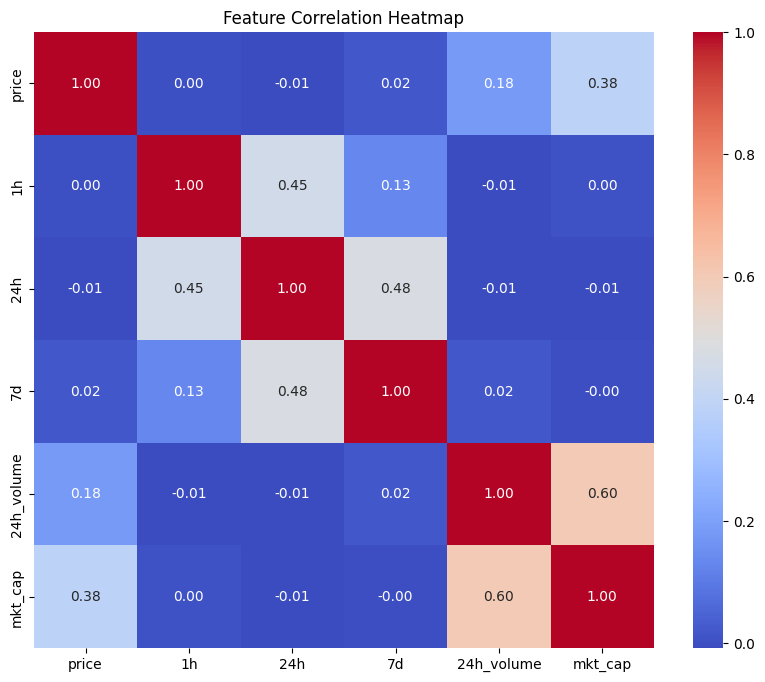

In [32]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


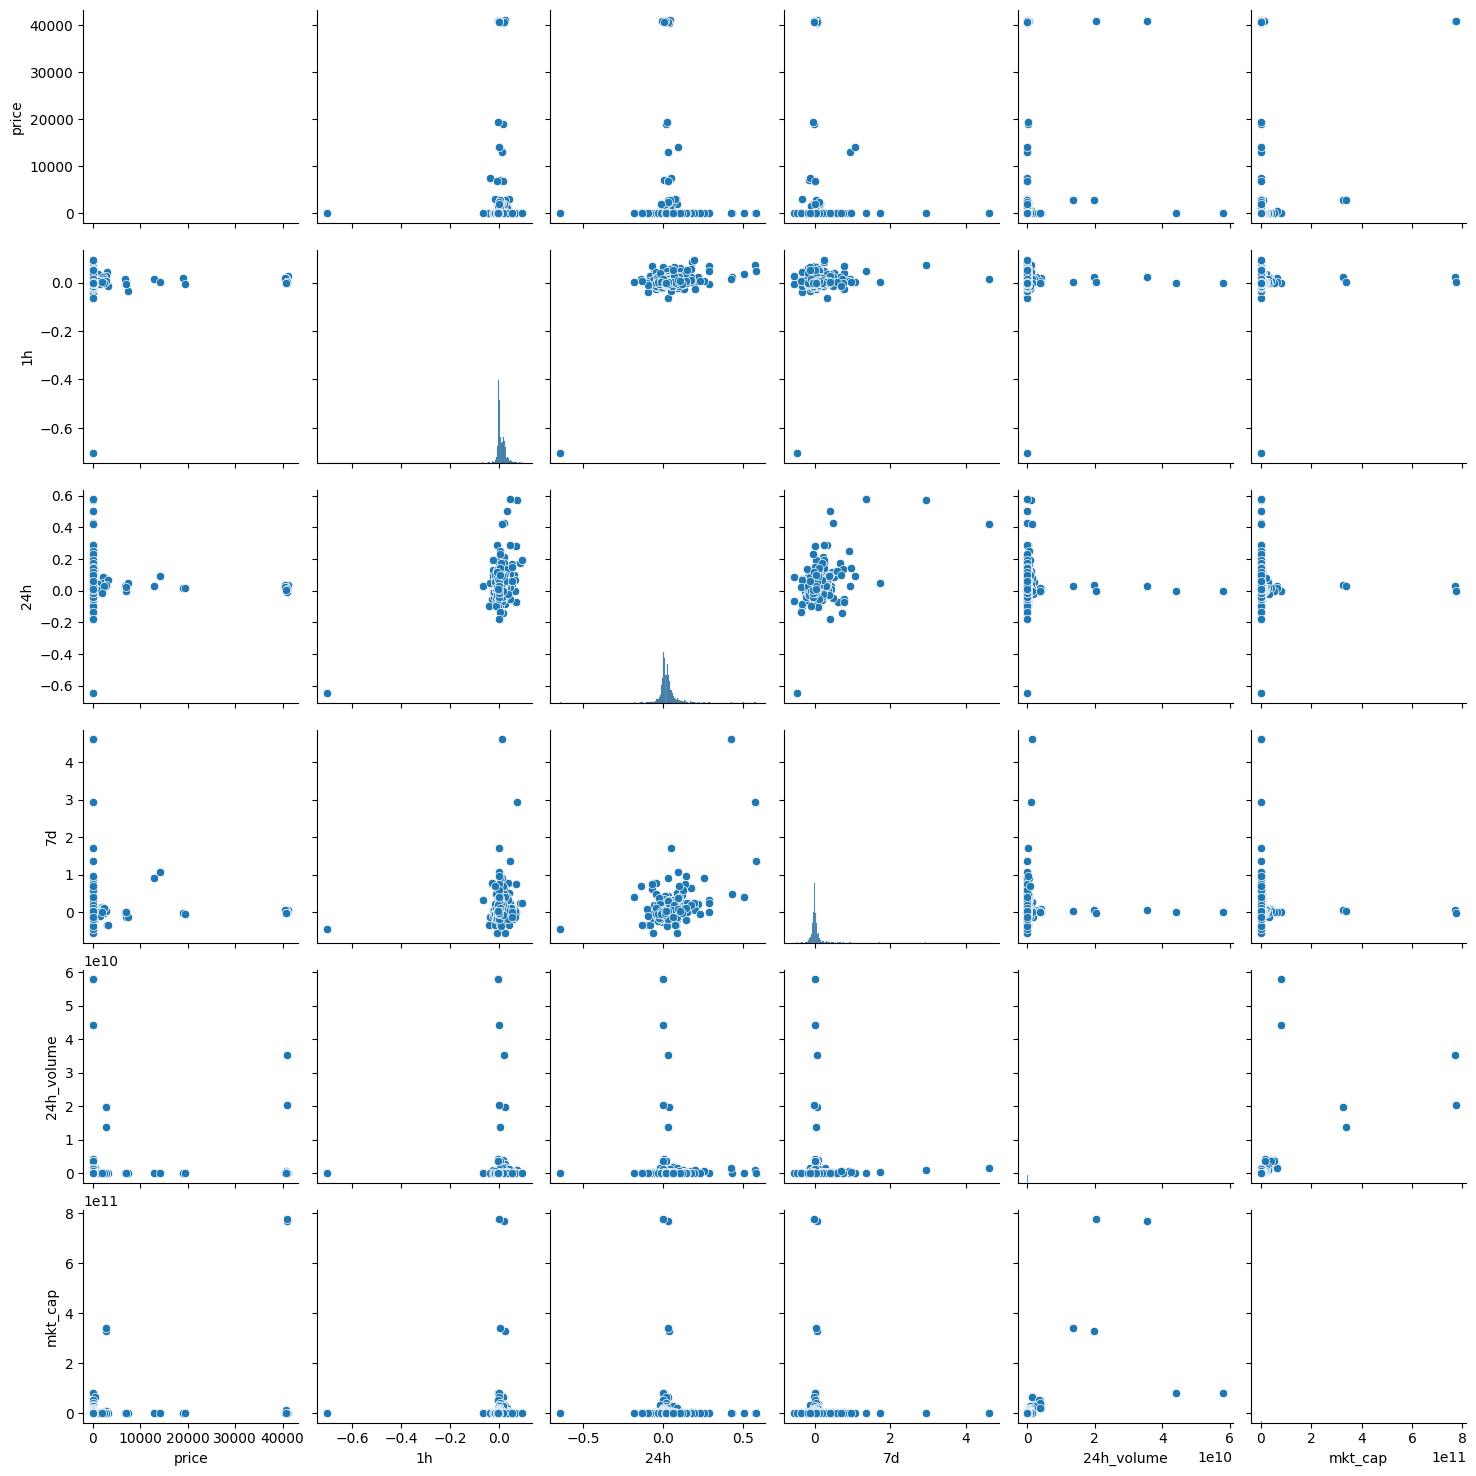

In [34]:
#Pairplots (Optional Extra Visualization)
sns.pairplot(df_features)
plt.show()


Step 4: Feature Engineering (In-Depth)

In [36]:
# Reload the unscaled features (if needed)
import pandas as pd
df = pd.read_csv('data/crypto_combined.csv')

# 1. 5-day Moving Average of Price
df['price_ma_5'] = df.groupby('coin')['price'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# 2. 5-day Rolling Volatility (standard deviation)
df['price_volatility_5'] = df.groupby('coin')['price'].transform(lambda x: x.rolling(window=5, min_periods=1).std())

# 3. Volume to Market Cap Ratio
df['vol_mcap_ratio'] = df['24h_volume'] / df['mkt_cap']

# 4. Price Change Rate (absolute 24h % change)
df['price_change_rate'] = df['24h'].abs()

# Display first few rows
df.head()


,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date,price_ma_5,price_volatility_5,vol_mcap_ratio,price_change_rate
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16,40859.460000,NaN,0.045903,0.030
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16,2744.410000,NaN,0.060374,0.034
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16,1.000000,NaN,0.724503,0.001
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16,383.430000,NaN,0.021795,0.028
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16,0.999874,NaN,0.074150,0.000


In [40]:
# After feature creation
df.bfill(inplace=True)  # Correct modern way

# Confirm no missing values
df.isnull().sum()



coin                  0
symbol                0
price                 0
1h                    0
24h                   0
7d                    0
24h_volume            0
mkt_cap               0
date                  0
price_ma_5            0
price_volatility_5    1
vol_mcap_ratio        0
price_change_rate     0
dtype: int64

In [44]:
# Replace missing values with the column's mean (avoid inplace)
df['price_volatility_5'] = df['price_volatility_5'].fillna(df['price_volatility_5'].mean())

# Confirm no missing values
print(df.isnull().sum())


coin                  0
symbol                0
price                 0
1h                    0
24h                   0
7d                    0
24h_volume            0
mkt_cap               0
date                  0
price_ma_5            0
price_volatility_5    0
vol_mcap_ratio        0
price_change_rate     0
dtype: int64


 Step 5: Model Selection (In-Depth)

In [3]:
import pandas as pd

# Load the combined dataset
df = pd.read_csv('data/crypto_combined.csv')

# Recreate the new engineered features again
df['price_ma_5'] = df.groupby('coin')['price'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
df['price_volatility_5'] = df.groupby('coin')['price'].transform(lambda x: x.rolling(window=5, min_periods=1).std())
df['vol_mcap_ratio'] = df['24h_volume'] / df['mkt_cap']
df['price_change_rate'] = df['24h'].abs()

# Backward fill any missing
df.bfill(inplace=True)


In [5]:
# Define features and target
X = df[['price', '1h', '24h', '7d', '24h_volume', 'mkt_cap', 'price_ma_5', 'price_volatility_5', 'price_change_rate']]
y = df['vol_mcap_ratio']


In [7]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
from sklearn.model_selection import train_test_split

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# IMPORTANT: Drop rows with NaNs AFTER the split
# First, reset indices
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Now drop any rows where X_train has NaNs
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


In [13]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr = LinearRegression()

# Fit on cleaned training data
lr.fit(X_train, y_train)

# Predict on cleaned test data
y_pred_lr = lr.predict(X_test)


In [17]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

print("Linear Regression Performance:")
print("RMSE:", root_mean_squared_error(y_test, y_pred_lr))  # <--- NEW
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression Performance:
RMSE: 0.32925487778573836
MAE: 0.11192840415613362
R2 Score: -0.06393217259911443


Step 6: Model Training with Random Forest
Let's now train a Random Forest Re

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Initialize
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

print("Random Forest Performance:")
print("RMSE:", root_mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Performance:
RMSE: 0.18951362974050381
MAE: 0.035612872017992896
R2 Score: 0.647523306271877


Step 7: Train XGBoost Regressor

In [23]:
from xgboost import XGBRegressor

# Initialize
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluate
print("XGBoost Performance:")
print("RMSE:", root_mean_squared_error(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))


XGBoost Performance:
RMSE: 0.20150493945950168
MAE: 0.03280044615894265
R2 Score: 0.6015068141153093


Step 8: (Optional Small Step) Feature Importance

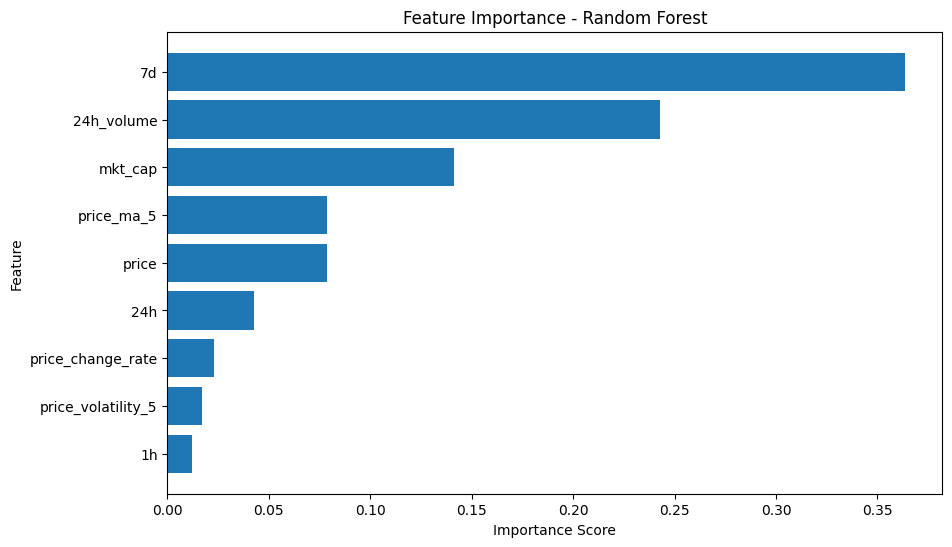

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
importances = rf.feature_importances_
features = X.columns

# Create DataFrame
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()


Step 9: Hyperparameter Tuning (Random Forest)

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Set parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize Random Forest
rf = RandomForestRegressor(random_state=42)

# Initialize Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,              # 3-fold cross validation
    n_jobs=-1,          # Use all processors
    verbose=2,          # Show progress
    scoring='r2'        # Use R² score for best model
)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters Found:", grid_search.best_params_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [29]:
# Import
from sklearn.ensemble import RandomForestRegressor

# Final Model
final_rf = RandomForestRegressor(
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

# Train
final_rf.fit(X_train, y_train)

# Predict
y_pred_final = final_rf.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

print("Final Random Forest Performance:")
print("RMSE:", root_mean_squared_error(y_test, y_pred_final))
print("MAE:", mean_absolute_error(y_test, y_pred_final))
print("R2 Score:", r2_score(y_test, y_pred_final))


Final Random Forest Performance:
RMSE: 0.19550971902052494
MAE: 0.051558899617869344
R2 Score: 0.624866188380564


 Step 10: Local Deployment (Streamlit App)

In [9]:
# 1. Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 2. Load your data again
df = pd.read_csv('data/crypto_combined.csv')

# 3. Feature engineering again
df['price_ma_5'] = df.groupby('coin')['price'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
df['price_volatility_5'] = df.groupby('coin')['price'].transform(lambda x: x.rolling(window=5, min_periods=1).std())
df['vol_mcap_ratio'] = df['24h_volume'] / df['mkt_cap']
df['price_change_rate'] = df['24h'].abs()
df.bfill(inplace=True)

# 4. Define X and y
X = df[['price', '1h', '24h', '7d', '24h_volume', 'mkt_cap', 'price_ma_5', 'price_volatility_5', 'price_change_rate']]
y = df['vol_mcap_ratio']

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# (Important) Drop any NaNs from X_train/y_train
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

# 6. Recreate Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# 7. Fit Random Forest
rf.fit(X_train, y_train)

# 8. Save the model
import os
import pickle

if not os.path.exists('models'):
    os.makedirs('models')

with open('models/final_rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)


In [11]:
# Load the saved model and predict
with open('models/final_rf_model.pkl', 'rb') as f:
    loaded_rf = pickle.load(f)

# Predict on a few examples
print(loaded_rf.predict(X_test[:5]))


[0.00552703 0.00325946 0.04019958 0.0846782  0.00111014]


In [13]:
# app/app.py

import streamlit as st
import pickle
import numpy as np

# Load the trained Random Forest model
with open('models/final_rf_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Streamlit App Title
st.title('🚀 Cryptocurrency Liquidity Prediction')
    
st.markdown("""
Welcome to the **Cryptocurrency Liquidity Prediction App**!  
Fill in the market details below to predict the **Liquidity Ratio** of a cryptocurrency. 📈
""")

# Input fields for user
price = st.number_input('Current Price (in USD)', min_value=0.0, format="%.4f")
change_1h = st.number_input('Price Change in 1h (%)', format="%.4f")
change_24h = st.number_input('Price Change in 24h (%)', format="%.4f")
change_7d = st.number_input('Price Change in 7d (%)', format="%.4f")
volume_24h = st.number_input('Trading Volume in last 24h (USD)', min_value=0.0, format="%.4f")
market_cap = st.number_input('Market Capitalization (USD)', min_value=0.0, format="%.4f")
price_ma_5 = st.number_input('5-Day Moving Average of Price', min_value=0.0, format="%.4f")
price_volatility_5 = st.number_input('5-Day Price Volatility', min_value=0.0, format="%.4f")
price_change_rate = st.number_input('Absolute 24h Price Change (%)', format="%.4f")

# Prediction button
if st.button('Predict Liquidity Ratio'):
    # Create input array
    input_data = np.array([[price, change_1h, change_24h, change_7d, volume_24h, market_cap, price_ma_5, price_volatility_5, price_change_rate]])
    
    # Predict using model
    prediction = model.predict(input_data)
    
    # Display prediction
    st.success(f'🔮 Predicted Liquidity Ratio: {prediction[0]:.6f}')

st.markdown("---")
st.markdown("© 2025 Sahil Sutar - Data Science Project 🚀")


2025-04-27 18:57:54.050 
  command:

    streamlit run C:\Users\Sahil Sutar\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-04-27 18:57:54.051 Session state does not function when running a script without `streamlit run`


DeltaGenerator()

In [1]:
import os
print(os.getcwd())


C:\Users\Sahil Sutar


In [3]:
!pip install streamlit
